# **Naïve Bayes**

##### Business Case: Spam Email Classification
##### Simulate Spam Email Dataset

In [65]:
import pandas as pd
import numpy as np

np.random.seed(36)
n = 500

# Generate a synthetic dataset
spam_data = pd.DataFrame({
    'email_length': np.random.normal(loc=150, scale=50, size=n).round(),
    'num_links': np.random.poisson(lam=2, size=n),
    'has_attachment': pd.Series(np.random.binomial(n=1, p=0.3, size=n)).map({0: "no", 1: "yes"}).astype('category'),
    'num_spam_words': np.random.poisson(lam=3, size=n)
})

spam_data['is_spam'] = np.where((spam_data['num_spam_words'] > 2) & ((spam_data['num_links'] > 1) | (spam_data['has_attachment'] == "yes")), 
                                "yes", "no")

spam_data['is_spam'] = spam_data['is_spam'].astype('category')

spam_data.head(6)

,email_length,num_links,has_attachment,num_spam_words,is_spam
0,184.0,3,yes,1,no
1,226.0,1,no,2,no
2,124.0,2,no,1,no
3,208.0,2,yes,5,yes
4,120.0,1,yes,0,no
5,112.0,3,yes,3,yes


##### **1. Exploratory Data Analysis**

In [66]:
spam_data.describe()

,email_length,num_links,num_spam_words
count,500.000000,500.000000,500.00000
mean,148.252000,2.042000,2.99000
std,52.741139,1.384221,1.81231
min,2.000000,0.000000,0.00000
25%,113.000000,1.000000,2.00000
50%,146.500000,2.000000,3.00000
75%,181.000000,3.000000,4.00000
max,311.000000,9.000000,10.00000


In [67]:
spam_data.describe(include='category')

,has_attachment,is_spam
count,500,500
unique,2,2
top,no,no
freq,349,298


**1. Tabulate the target variable is_spam and interpret its class balance.**

In [68]:
# Count how many emails are labeled as spam ("yes") vs. not spam ("no")
spam_data['is_spam'].value_counts()

is_spam
no     298
yes    202
Name: count, dtype: int64

In [69]:
# Show the proportions (relative frequencies) of each class
spam_data['is_spam'].value_counts(normalize=True)

is_spam
no     0.596
yes    0.404
Name: proportion, dtype: float64

**2. Group-wise means of numeric features by spam class**

In [70]:
spam_data.groupby('is_spam')[['num_links', 'email_length', 'num_spam_words']].mean()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13924\2932375278.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spam_data.groupby('is_spam')[['num_links', 'email_length', 'num_spam_words']].mean()


,num_links,email_length,num_spam_words
is_spam,,,
no,1.687919,145.875839,2.151007
yes,2.564356,151.757426,4.227723


**3. Plot the distribution of num_links and compute its skewness.**

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of number of links in emails
sns.set_style('darkgrid')
sns.histplot(data=spam_data, x='num_links', binwidth=1, color='steelblue')
plt.title("Distribution of Number of Links")
plt.xlabel("Number of Links")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

In [72]:
from scipy.stats import skew

# Compute skewness of the distribution
skew(spam_data['num_links'], bias=True)

np.float64(0.6553636692098828)

**4. Plot the distribution of num_spam_words and compute its skewness.**

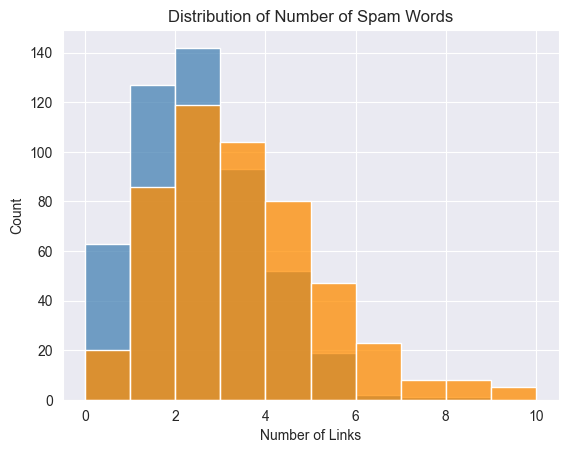

In [73]:
sns.set_style('darkgrid')
sns.histplot(data=spam_data, x='num_spam_words', binwidth=1, color="darkorange")
plt.title("Distribution of Number of Spam Words")
plt.show()

In [74]:
skew(spam_data['num_spam_words'], bias=True)

np.float64(0.8418956394422441)

**5. Plot the distribution of email_length and compute its skewness**

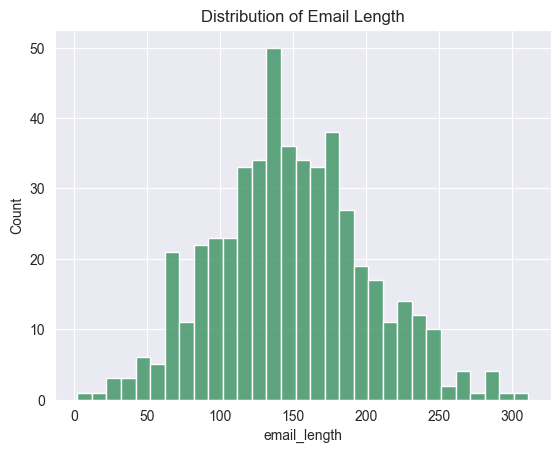

In [75]:
sns.set_style('darkgrid')
sns.histplot(data=spam_data, x='email_length', binwidth=10, color="seagreen")
plt.title("Distribution of Email Length")
plt.show()

In [76]:
skew(spam_data['email_length'])

np.float64(0.17784408376086688)

**6. Create a cross-tab of has_attachment vs. is_spam.**

In [77]:
pd.crosstab(spam_data['has_attachment'], spam_data['is_spam'], margins=True)

is_spam,no,yes,All
has_attachment,,,
no,226,123,349
yes,72,79,151
All,298,202,500


In [78]:
pd.crosstab(spam_data['has_attachment'], spam_data['is_spam'], margins=True, normalize=True)

is_spam,no,yes,All
has_attachment,,,
no,0.452,0.246,0.698
yes,0.144,0.158,0.302
All,0.596,0.404,1.000


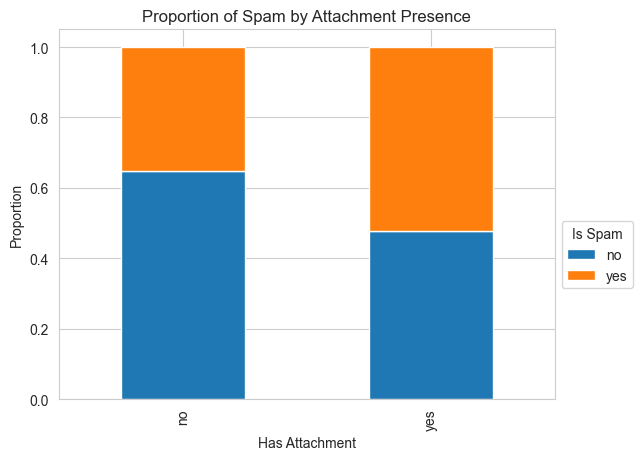

In [79]:
count_df = pd.crosstab(spam_data['has_attachment'], spam_data['is_spam'])
count_df_prop = count_df.div(count_df.sum(axis=1), axis=0)

sns.set_style('whitegrid')
count_df_prop.plot(kind='bar', stacked=True)
plt.title("Proportion of Spam by Attachment Presence")
plt.xlabel("Has Attachment")
plt.ylabel("Proportion")
plt.legend(title="Is Spam", bbox_to_anchor=(1,0.5))
plt.show()

##### **2. Train/Test Split**

In [80]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(spam_data, test_size=0.3, stratify=spam_data['is_spam'], random_state=123)

full_dist = spam_data['is_spam'].value_counts(normalize=True)
train_dist = train['is_spam'].value_counts(normalize=True)
test_dist = test['is_spam'].value_counts(normalize=True)

print("Class Distribution in Full Dataset:\n")
print(full_dist.round(3))

print("Class Distribution in Training Set:")
print(train_dist.round(3))

print("Class Distribution in Testing Set:")
print(test_dist.round(3))

Class Distribution in Full Dataset:

is_spam
no     0.596
yes    0.404
Name: proportion, dtype: float64
Class Distribution in Training Set:
is_spam
no     0.597
yes    0.403
Name: proportion, dtype: float64
Class Distribution in Testing Set:
is_spam
no     0.593
yes    0.407
Name: proportion, dtype: float64


##### **3. Train Multiple Naïve Bayes Models**

**Model 1: is_spam ~ num_spam_words**

In [81]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import confusion_matrix, classification_report

model1 = GaussianNB() #Initially we applied the Multinomial method, but R identifies it as a continuous or numeric variable ('num_spam_words' is discrete distribution), so you need to apply the Gaussian method
model1.fit(train[['num_spam_words']], train['is_spam'])

# Make predictions
pred1 = model1.predict(test[['num_spam_words']])
prob1 = model1.predict_proba(test[['num_spam_words']])

# Confusion matrix
cm1 = confusion_matrix(test['is_spam'], pred1, labels=['no', 'yes'])
print("Confusion matrix:\n", cm1)

print("Classification Report:\n", classification_report(test['is_spam'], pred1, target_names=['no', 'yes']))

Confusion matrix:
 [[76 13]
 [27 34]]
Classification Report:
               precision    recall  f1-score   support

          no       0.74      0.85      0.79        89
         yes       0.72      0.56      0.63        61

    accuracy                           0.73       150
   macro avg       0.73      0.71      0.71       150
weighted avg       0.73      0.73      0.73       150



In [98]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Model fit metrics

acc1 = accuracy_score(test['is_spam'], pred1)
pre1 = precision_score(test['is_spam'], pred1, pos_label="yes")
re1 = recall_score(test['is_spam'], pred1, pos_label="yes")
fs1 = f1_score(test['is_spam'], pred1, pos_label="yes")

print("Accuracy: ", acc1)
print("Precision: ", pre1)
print("Sensitivity: ", re1)
print("F1-Score: ", fs1)

Accuracy:  0.7333333333333333
Precision:  0.723404255319149
Sensitivity:  0.5573770491803278
F1-Score:  0.6296296296296297


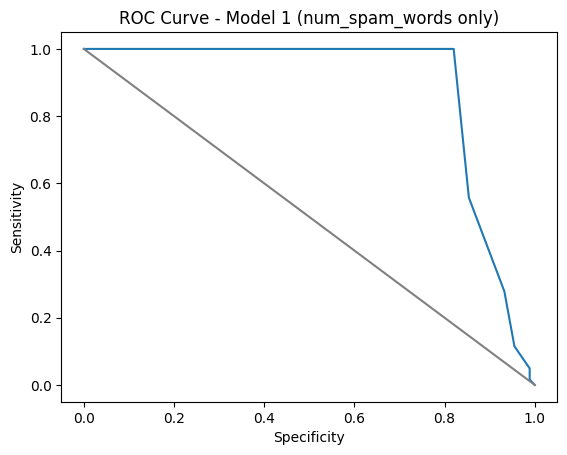

AUC:  0.8866273715233007


In [83]:
from sklearn.metrics import roc_curve, auc

# ROC curve and AUC
fpr, tpr, threshold = roc_curve(test['is_spam'], prob1[:, 1], pos_label="yes")
roc_auc = auc(fpr, tpr)

sns.reset_orig()
plt.figure()
plt.plot(1-fpr, tpr)
plt.plot([1,0], [0,1], color="gray")
plt.title("ROC Curve - Model 1 (num_spam_words only)")
plt.xlabel("Specificity")
plt.ylabel("Sensitivity")
plt.show()

print("AUC: ",roc_auc)

**Model 2: is_spam ~ num_spam_words + num_links**

In [84]:
model2 = GaussianNB()
model2.fit(train[['num_spam_words','num_links']], train['is_spam'])

# Make predictions:
pred2 = model2.predict(test[['num_spam_words','num_links']])
prob2 = model2.predict_proba(test[['num_spam_words','num_links']])

# Confussion matrix
cm2 = confusion_matrix(test['is_spam'], pred2, labels=['no', 'yes'])
print("Confusion matrix:\n", cm2)

print("Classification Report:\n", classification_report(test['is_spam'], pred2, target_names=['no', 'yes']))

Confusion matrix:
 [[83  6]
 [23 38]]
Classification Report:
               precision    recall  f1-score   support

          no       0.78      0.93      0.85        89
         yes       0.86      0.62      0.72        61

    accuracy                           0.81       150
   macro avg       0.82      0.78      0.79       150
weighted avg       0.82      0.81      0.80       150



In [99]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Model fit metrics

acc2 = accuracy_score(test['is_spam'], pred2)
pre2 = precision_score(test['is_spam'], pred2, pos_label="yes")
re2 = recall_score(test['is_spam'], pred2, pos_label="yes")
fs2 = f1_score(test['is_spam'], pred2, pos_label="yes")

print("Accuracy: ", acc2)
print("Precision: ", pre2)
print("Sensitivity: ", re2)
print("F1-Score: ", fs2)

Accuracy:  0.8066666666666666
Precision:  0.8636363636363636
Sensitivity:  0.6229508196721312
F1-Score:  0.7238095238095238


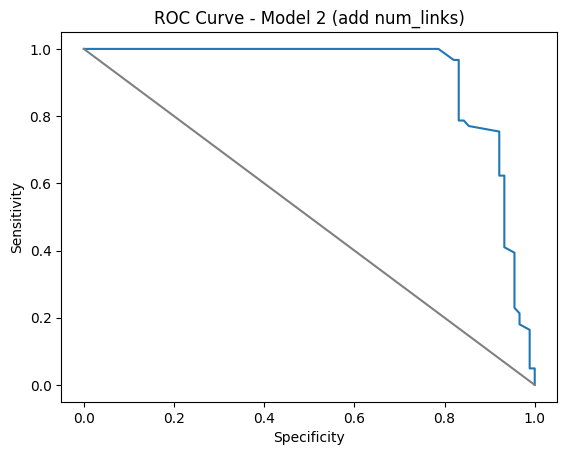

AUC:  0.9224534905139068


In [86]:
from sklearn.metrics import roc_curve, auc

# ROC Curve and AUC
fpr2, tpr2, threshold2 = roc_curve(test['is_spam'], prob2[:, 1], pos_label="yes")
roc_auc2 = auc(fpr2, tpr2)

plt.figure()
plt.plot(1-fpr2, tpr2)
plt.plot([1,0], [0,1], color="gray")
plt.title("ROC Curve - Model 2 (add num_links)")
plt.xlabel("Specificity")
plt.ylabel("Sensitivity")
plt.show()

print("AUC: ", roc_auc2)

**Model 3: is_spam ~ num_spam_words + num_links + has_attachment**

In [88]:
train['has_attachment'] = train['has_attachment'].replace({'no':0, 'yes':1})
test['has_attachment'] = test['has_attachment'].replace({'no':0, 'yes':1})

model3 = GaussianNB()
model3.fit(train[['num_spam_words','has_attachment','num_links']], train['is_spam'])

# Make predictions
pred3 = model3.predict(test[['num_spam_words','has_attachment','num_links']])
prob3 = model3.predict_proba(test[['num_spam_words','has_attachment','num_links']])

# Confussion matrix
cm3 = confusion_matrix(test['is_spam'], pred3, labels=['no','yes'])

print("Confussion matrix:\n", cm3)
print("Classification Report:\n", classification_report(test['is_spam'], pred3, target_names=['no','yes']))

Confussion matrix:
 [[82  7]
 [24 37]]
Classification Report:
               precision    recall  f1-score   support

          no       0.77      0.92      0.84        89
         yes       0.84      0.61      0.70        61

    accuracy                           0.79       150
   macro avg       0.81      0.76      0.77       150
weighted avg       0.80      0.79      0.79       150



C:\Users\ASUS\AppData\Local\Temp\ipykernel_13924\3895700885.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train['has_attachment'] = train['has_attachment'].replace({'no':0, 'yes':1})
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13924\3895700885.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  train['has_attachment'] = train['has_attachment'].replace({'no':0, 'yes':1})
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13924\3895700885.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To re

In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Model fit metrics

acc3 = accuracy_score(test['is_spam'], pred3)
pre3 = precision_score(test['is_spam'], pred3, pos_label="yes")
re3 = recall_score(test['is_spam'], pred3, pos_label="yes")
fs3 = f1_score(test['is_spam'], pred3, pos_label="yes")

print("Accuracy: ", acc3)
print("Precision: ", pre3)
print("Sensitivity: ", re3)
print("F1-Score: ", fs3)

Accuracy:  0.7933333333333333
Precision:  0.8409090909090909
Sensitivity:  0.6065573770491803
F1-Score:  0.7047619047619048


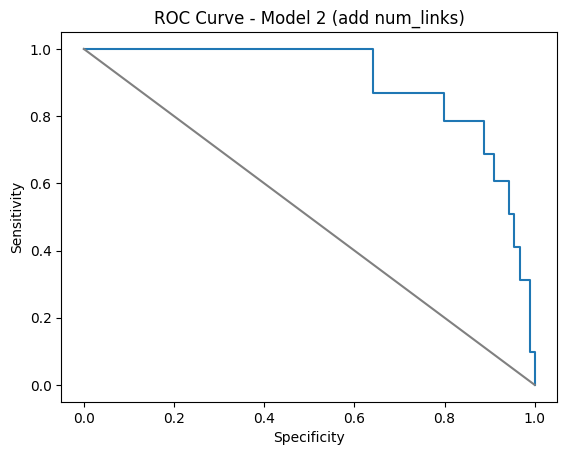

AUC:  0.9021919322158776


In [90]:
from sklearn.metrics import roc_curve, auc

# ROC Curve and AUC
fpr3, tpr3, threshold3 = roc_curve(test['is_spam'], prob3[:, 1], pos_label="yes")
roc_auc3 = auc(fpr3, tpr3)

plt.figure()
plt.plot(1-fpr3, tpr3)
plt.plot([1,0], [0,1], color="gray")
plt.title("ROC Curve - Model 2 (add num_links)")
plt.xlabel("Specificity")
plt.ylabel("Sensitivity")
plt.show()

print("AUC: ", roc_auc3)

**Model 4: All predictors**

In [93]:
model4 = GaussianNB()
model4.fit(train.drop(columns=['is_spam']), train['is_spam'])

# Make predictions
pred4 = model4.predict(test.drop(columns=['is_spam']))
prob4 = model4.predict_proba(test.drop(columns=['is_spam']))

# Confussion matrix
cm4 = confusion_matrix(test['is_spam'], pred4, labels=['no','yes'])

print("Confussion matrix:\n", cm4)
print("Classification Report:\n", classification_report(test['is_spam'], pred4, target_names=['no','yes']))

Confussion matrix:
 [[80  9]
 [22 39]]
Classification Report:
               precision    recall  f1-score   support

          no       0.78      0.90      0.84        89
         yes       0.81      0.64      0.72        61

    accuracy                           0.79       150
   macro avg       0.80      0.77      0.78       150
weighted avg       0.80      0.79      0.79       150



In [101]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Model fit metrics

acc4 = accuracy_score(test['is_spam'], pred4)
pre4 = precision_score(test['is_spam'], pred4, pos_label="yes")
re4 = recall_score(test['is_spam'], pred4, pos_label="yes")
fs4 = f1_score(test['is_spam'], pred4, pos_label="yes")

print("Accuracy: ", acc4)
print("Precision: ", pre4)
print("Sensitivity: ", re4)
print("F1-Score: ", fs4)

Accuracy:  0.7933333333333333
Precision:  0.8125
Sensitivity:  0.639344262295082
F1-Score:  0.7155963302752294


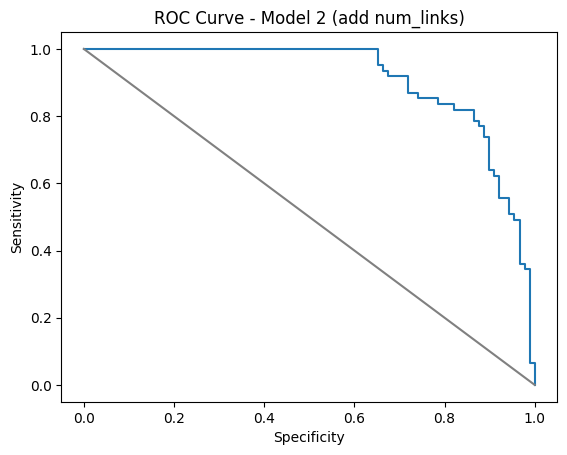

AUC:  0.9093755756124517


In [96]:
from sklearn.metrics import roc_curve, auc

# ROC Curve and AUC
fpr4, tpr4, threshold4 = roc_curve(test['is_spam'], prob4[:, 1], pos_label="yes")
roc_auc4 = auc(fpr4, tpr4)

plt.figure()
plt.plot(1-fpr4, tpr4)
plt.plot([1,0], [0,1], color="gray")
plt.title("ROC Curve - Model 2 (add num_links)")
plt.xlabel("Specificity")
plt.ylabel("Sensitivity")
plt.show()

print("AUC: ", roc_auc4)

##### **4. Compare Multiple Models**

In [105]:
comparison = pd.DataFrame({
    'features': ['num_spam_words','num_spam_words + num_links','num_spam_words + num_links + has_attachment','all predictors'],
    'accuracy': np.round([acc1, acc2, acc3, acc4],3),
    'precision': np.round([pre3, pre3, pre3, pre4],3),
    'recall': np.round([re1, re2, re3, re4],3),
    'f1_score': np.round([fs1, fs2, fs3, fs4],3),
    'auc': np.round([roc_auc, roc_auc2, roc_auc3, roc_auc4],3)
})

comparison

,features,accuracy,precision,recall,f1_score,auc
0,num_spam_words,0.733,0.841,0.557,0.630,0.887
1,num_spam_words + num_links,0.807,0.841,0.623,0.724,0.922
2,num_spam_words + num_links + has_attachment,0.793,0.841,0.607,0.705,0.902
3,all predictors,0.793,0.812,0.639,0.716,0.909
